In [2]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import time
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
from konlpy.tag import Okt
from gensim import corpora, models
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis
from wordcloud import WordCloud

%matplotlib inline
# 그래프에 한글이 깨지지 않게
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False


## google

In [3]:
data = pd.read_excel('google scholar data.xls')

In [4]:
data = data.reset_index()

In [5]:
data = data.drop(['index'],axis = 1)

In [6]:
data.isnull().sum()

Unnamed: 0      0
논문 제목           1
저널              1
연도              1
초록            372
dtype: int64

In [7]:
data = data.dropna()

In [8]:
data = data.reset_index()

In [9]:
data = data.drop(['index'],axis = 1)

In [10]:
data['저널'].unique()

array(['지하공간,', 'Health,', 'health,', '…,', '현실,', '한국운동역학회지,', '자료집,',
       '한국사회체육학회지,', '논문집,', '한국자원공학회지,', '한국역학회지,', '학술대회논문집,',
       '중국어문논역총간,', '기술,', 'Korea,', '월간산업보건,', '-', 'Nursing,',
       'Medicine,', 'Ecology,', '리뷰,', '학술대회,', '한국운동학회지,', 'Technology,',
       '중국인문과학,', 'Nutr,', '한국지역지리학회지,', '국제정치연구,', '코칭능력개발지,',
       '한국체육과학회지,', '영문초록집,', 'Conference,', '한국동양정치사상사연구,',
       '보건교육건강증진학회지,', 'Geology,', '한국체육철학회지,', '한국여성체육학회지,', '번역학연구,',
       '논문지,', '대한인간공학회지,', '학술지,', '동의생리병리학회지,', '라틴아메리카연구,', '제,',
       '아시아문화,', '역사학보,', '외국문학연구,', '도교문화연구,', '기계저널,', '한국어학,',
       '한국웰니스학회지,', '한국체육측정평가학회지,', '정보관리연구,', '한국예술연구,', '추계학술대회,',
       '(한국지반공학회지),', '장신논단,', 'Mathematics,', '담론,', '중국어문학논집,', '철학논총,',
       '재활복지공학회논문지,', 'Agriculture,', 'KOSHAM,', '한국콘텐츠학회논문지,', '코기토,',
       '중국문화연구,', '운동학학술지,', '한국체육교육학회지,', '대한전자공학회', '체육과학연구,',
       '보건복지포럼,', '.', '대한조선학회지,', '중어중문학,', '정책,', '충청문화연구,',
       '한국초등체육학회지,', '인권,', '통상정보연구,', '동악어문학,'

In [11]:
data.loc[data['저널'] == '한국운동역학회지,', '저널'] = '한국운동역학회지'

In [12]:
data['연도'] = data['연도'].astype(int)

In [13]:
data = data[data['저널'] == "한국운동역학회지"]

In [14]:
data = data.drop_duplicates(subset=['논문 제목'])

In [15]:
data = data.drop(['Unnamed: 0'],axis = 1)

In [16]:
data = data.reset_index()

In [17]:
data = data.drop(['index'],axis = 1)

In [18]:
data

,논문 제목,저널,연도,초록
0,야구와 핸드볼 공 던지기 동작의 비교 분석,한국운동역학회지,1994,The goal of this research is to make a compara...
1,인체 공중 동작 시뮬레이션 프로그램 개발,한국운동역학회지,1994,A comprehensive simulation software package wa...
2,인체이동에 관한 운동역학적 분석 1,한국운동역학회지,1994,"During walking, jogging and sprinting, the sup..."
3,에어로빅스 운동시 부상 유발 동작의 운동 역학적 분석,한국운동역학회지,1995,One of the reason that the aerobic dance is po...
4,검도 머리치기 동작의 운동학적 연구,한국운동역학회지,1995,The purpose of this study is to construct a mo...
...,...,...,...,...
1696,8 주간 속도 기반 트레이닝이 전문 운동선수의 근력과 근 파워 능력에 미치는 영향,한국운동역학회지,2024,Objective: The purpose of this study is to app...
1697,8 주간 속도 기반 트레이닝이 단거리 육상선수의 순발력에 미치는 영향,한국운동역학회지,2024,Objective: The purpose of this study was to ev...
1698,바벨 백 스쿼트 시 운동 속도 조건에 따른 하지 근 활성도 및 무릎 관절의 부하량 비교,한국운동역학회지,2024,Objective: The purpose of this study was to co...
1699,컴파운드 양궁의 팔로우 스루 동작과 사격 정확도의 상관관계,한국운동역학회지,2024,Objective: This study aimed to investigate how...


## 중복 논문 제거

제목만 중복 제거하면 부족하다.
같은 논문이 **국문 제목판과 영문 제목판으로 두 번** 등록돼 있기 때문이다.
예) `클럽의 길이 변화에 따른 골프 스윙의 지면반력 변화`
  = `Changes of ground reaction forces by the change of club length in golf`

In [19]:
# ============================================
# 1️⃣ 초록 정리용 컬럼 만들기
# ============================================
# 같은 초록인데 대소문자나 공백이 달라서 다르게 보이는 경우가 있다.
# 소문자로 바꾸고 여러 칸 띄어쓰기를 한 칸으로 정리해서 비교용 컬럼을 만든다
data['초록정리'] = (data['초록'].str.lower()
                          .str.replace(r'\s+', ' ', regex=True)
                          .str.strip())
data[['초록', '초록정리']].head(2)

,초록,초록정리
0,The goal of this research is to make a compara...,the goal of this research is to make a compara...
1,A comprehensive simulation software package wa...,a comprehensive simulation software package wa...


In [20]:
# ============================================
# 2️⃣ 초록이 없는 논문 제거
# ============================================
# 초록 자리에 'No abstract available' 이 들어있는 논문이 있다
data = data[data['초록정리'] != 'no abstract available']
print(len(data), '편')

1689 편


In [21]:
# ============================================
# 3️⃣ 초록이 완전히 똑같은 논문 제거
# ============================================
data = data.drop_duplicates(subset=['초록정리'])
print(len(data), '편')

1448 편


In [22]:
# ============================================
# 4️⃣ 초록이 거의 똑같은 논문 제거 (국문판 / 영문판 중복)
# ============================================
# 같은 논문이 '국문 제목판' 과 '영문 제목판' 으로 두 번 등록돼 있다.
# 국문판 초록은 '국문초록 + 영문초록' 이라 텍스트가 완전히 같지는 않다.
# 그래서 초록의 영어 단어가 70% 이상 겹치면 같은 논문으로 본다.
#
# 단, 제목 언어까지 같으면 같은 연구팀의 다른 논문일 수 있어서 남긴다.
#   예) '유도 업어치기의 3차원 역학적 특성 분석'
#       '유도 우수선수 업어치기의 3차원 역학적 특성 프로화일'  → 서로 다른 논문
import re

# 초록에서 3글자 이상 영어 단어만 뽑아 집합으로 만든다
words = data['초록'].apply(lambda s: set(re.findall(r'[a-z]{3,}', str(s).lower())))

# 제목에 한글이 있으면 국문 제목, 없으면 영문 제목
title_lang = data['논문 제목'].apply(
    lambda t: '국문' if re.search(r'[가-힣]', str(t)) else '영문')

dup = []
for year, group in data.groupby('연도'):
    keep = []
    for i in group.index:
        same = False
        for j in keep:
            overlap = len(words[i] & words[j]) / len(words[i] | words[j])
            if overlap >= 0.7 and title_lang[i] != title_lang[j]:
                same = True
                break
        if same:
            dup.append(i)      # 국문판/영문판 중복이니 버림
        else:
            keep.append(i)     # 남김

data = data.drop(dup)
print(len(dup), '편 제거 →', len(data), '편')

328 편 제거 → 1120 편


In [23]:
data = data.reset_index()

In [24]:
data = data.drop(['index'],axis = 1)

In [25]:
data

,논문 제목,저널,연도,초록,초록정리
0,야구와 핸드볼 공 던지기 동작의 비교 분석,한국운동역학회지,1994,The goal of this research is to make a compara...,the goal of this research is to make a compara...
1,인체 공중 동작 시뮬레이션 프로그램 개발,한국운동역학회지,1994,A comprehensive simulation software package wa...,a comprehensive simulation software package wa...
2,인체이동에 관한 운동역학적 분석 1,한국운동역학회지,1994,"During walking, jogging and sprinting, the sup...","during walking, jogging and sprinting, the sup..."
3,에어로빅스 운동시 부상 유발 동작의 운동 역학적 분석,한국운동역학회지,1995,One of the reason that the aerobic dance is po...,one of the reason that the aerobic dance is po...
4,검도 머리치기 동작의 운동학적 연구,한국운동역학회지,1995,The purpose of this study is to construct a mo...,the purpose of this study is to construct a mo...
...,...,...,...,...,...
1115,8 주간 속도 기반 트레이닝이 전문 운동선수의 근력과 근 파워 능력에 미치는 영향,한국운동역학회지,2024,Objective: The purpose of this study is to app...,objective: the purpose of this study is to app...
1116,8 주간 속도 기반 트레이닝이 단거리 육상선수의 순발력에 미치는 영향,한국운동역학회지,2024,Objective: The purpose of this study was to ev...,objective: the purpose of this study was to ev...
1117,바벨 백 스쿼트 시 운동 속도 조건에 따른 하지 근 활성도 및 무릎 관절의 부하량 비교,한국운동역학회지,2024,Objective: The purpose of this study was to co...,objective: the purpose of this study was to co...
1118,컴파운드 양궁의 팔로우 스루 동작과 사격 정확도의 상관관계,한국운동역학회지,2024,Objective: This study aimed to investigate how...,objective: this study aimed to investigate how...


## 토픽모델링

### 왜 영어로 하는가

처음에는 `Okt().nouns()` 로 한국어 명사를 뽑았다. 그런데 이 학회지는 **초록이 대부분 영문**이다.
한국어 형태소 분석기는 영문에서 명사를 못 뽑기 때문에, 영문 제목 + 영문 초록인 논문은
토큰이 **0개**가 되어 분석에서 사실상 빠졌다.

| | 한국어(Okt) | 영어 |
|---|---|---|
| 논문당 평균 토큰 | 15.7 | **118.7** |
| 토큰 0개 논문 | 808편 (47.5%) | 0편 |

그래서 영어 기준으로 분석한다. 논문 제목이 한국어여도 초록이 영문이므로 문제없다.

In [26]:
# ============================================
# 5️⃣ 불용어 만들기
# ============================================
# 영어 기능어(the, and ...) + 논문에 무조건 나오는 말(study, purpose, result ...)
# 이런 단어는 어느 토픽에나 나와서 주제 구분에 도움이 안 된다
stop_words = set('''
a about above after again against all also am an and any are as at be because been
before being below between both but by can cannot could did do does doing down during
each few for from further had has have having he her here hers herself him himself his
how i if in into is it its itself me more most my myself no nor not of off on once only
or other ought our ours ourselves out over own same she should so some such than that
the their theirs them themselves then there these they this those through to too under
until up very was we were what when where which while who whom why with would you your
yours yourself yourselves upon among within without via thus therefore hence however
moreover furthermore whereas although though since
study studies research researches purpose purposes aim aims objective objectives goal
goals result results conclusion conclusions method methods methodology analysis analyses
analyze analyzed analyzing investigate investigated investigation examine examined
compare compared comparison comparing measure measured measurement measurements
subject subjects participant participants group groups sample samples data datum
present presented performed carried conducted obtained showed shown found significant
significantly difference differences differ value values used using use
paper article following followings order respectively
one two three four five six seven eight nine ten first second third
p ns sec s ms cm mm kg m n vs et al fig figs table tables kim lee park choi
'''.split())

print(len(stop_words), '개')

247 개


In [27]:
# ============================================
# 6️⃣ 형태소 분석 대신 영어 단어 추출
# ============================================
# 제목 + 초록을 합친 뒤 3글자 이상 영어 단어만 뽑고 불용어를 뺀다
data['text'] = data['논문 제목'].fillna('') + ' ' + data['초록'].fillna('')

texts = [[word for word in re.findall(r'[a-z]{3,}', str(sentence).lower())
          if word not in stop_words]
         for sentence in data['text']]

print('논문당 평균 단어 수 :', round(sum(len(t) for t in texts) / len(texts), 1))

논문당 평균 단어 수 : 118.5


In [28]:
# ============================================
# 7️⃣ 단어 사전(Dictionary) 및 코퍼스(Corpus) 생성
# ============================================
dictionary = corpora.Dictionary(texts)

# 10편 미만에만 나오는 단어(오타·고유명사)와
# 35% 넘는 논문에 나오는 단어(너무 흔해서 구분 안 됨)를 뺀다
dictionary.filter_extremes(no_below=10, no_above=0.35)

corpus = [dictionary.doc2bow(text) for text in texts]

print('사전 크기 :', len(dictionary))

사전 크기 :

 1383


## 토픽 개수(k) 정하기

**Coherence 는 클수록 좋다.** 토픽 안의 단어들이 실제로 같이 등장하는지를 재는 값이다.

주의할 점이 하나 있다. LDA 는 `random_state` 에 따라 결과가 달라진다.
같은 k 에서도 시드마다 0.02~0.07 씩 차이가 나서, 시드 하나로 비교하면
운 좋게 잘 나온 시드를 고르게 된다. 그래서 **시드 3개의 평균**을 본다.

(이 셀은 10분 정도 걸린다)

In [29]:
# ============================================
# 8️⃣ 토픽 개수별 Coherence 비교
# ============================================
from gensim.models import CoherenceModel
import statistics

seeds = [42, 7, 2024]
scores = []

for n in range(2, 10):
    values = []
    for seed in seeds:
        lda_model = models.LdaModel(corpus=corpus, num_topics=n, id2word=dictionary,
                                    passes=15, random_state=seed)
        coherence_model = CoherenceModel(model=lda_model, texts=texts,
                                         dictionary=dictionary, coherence='c_v',
                                         processes=1)
        values.append(coherence_model.get_coherence())

    scores.append((n, statistics.mean(values), statistics.stdev(values)))
    print(f"토픽 {n}개 → coherence 평균: {statistics.mean(values):.4f} "
          f"(표준편차 {statistics.stdev(values):.4f})")

best = max(scores, key=lambda x: x[1])
print(f"\ncoherence 가 가장 높은 토픽 개수 : {best[0]}개 ({best[1]:.4f})")

토픽 2개 → coherence 평균: 0.4148 (표준편차 0.0038)


토픽 3개 → coherence 평균: 0.4099 (표준편차 0.0037)


토픽 4개 → coherence 평균: 0.4133 (표준편차 0.0114)


토픽 5개 → coherence 평균: 0.4221 (표준편차 0.0209)


토픽 6개 → coherence 평균: 0.4702 (표준편차 0.0251)


토픽 7개 → coherence 평균: 0.4543 (표준편차 0.0203)


토픽 8개 → coherence 평균: 0.4446 (표준편차 0.0307)


토픽 9개 → coherence 평균: 0.4564 (표준편차 0.0132)

coherence 가 가장 높은 토픽 개수 : 6개 (0.4702)


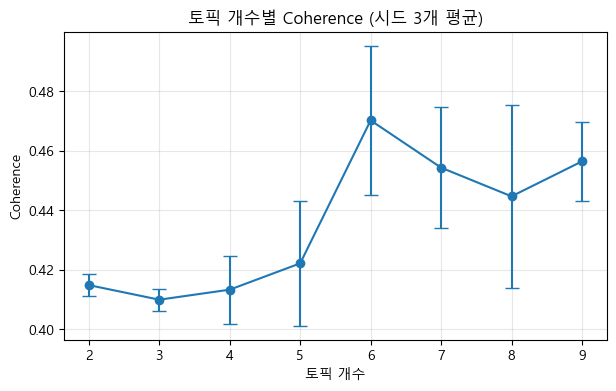

In [30]:
# ============================================
# 9️⃣ 그래프로 확인
# ============================================
plt.figure(figsize=(7, 4))
plt.errorbar([s[0] for s in scores], [s[1] for s in scores],
             yerr=[s[2] for s in scores], marker='o', capsize=5)
plt.xlabel('토픽 개수')
plt.ylabel('Coherence')
plt.title('토픽 개수별 Coherence (시드 3개 평균)')
plt.xticks([s[0] for s in scores])
plt.grid(alpha=0.3)
plt.show()

### num_topics가 6일때

Coherence 가 가장 높은 6개로 정했다.

In [31]:
# ============================================
# 🔟 LDA 토픽모델 학습
# ============================================
lda_model = models.LdaModel(
    corpus=corpus,
    num_topics=6,
    id2word=dictionary,
    passes=15,
    random_state=42
)

# 토픽별 주요 단어 출력
for idx, topic in lda_model.print_topics(num_words=10):
    print(f"🧩 토픽 {idx}: {topic}")

🧩 토픽 0: 0.022*"velocity" + 0.018*"angular" + 0.018*"rotation" + 0.014*"shoulder" + 0.012*"kinematic" + 0.011*"phase" + 0.010*"dimensional" + 0.010*"trunk" + 0.008*"speed" + 0.008*"upper"
🧩 토픽 1: 0.025*"running" + 0.023*"shoes" + 0.020*"force" + 0.017*"walking" + 0.012*"foot" + 0.011*"knee" + 0.011*"shoe" + 0.011*"peak" + 0.010*"heel" + 0.010*"jump"
🧩 토픽 2: 0.035*"swing" + 0.033*"foot" + 0.025*"pressure" + 0.018*"golf" + 0.017*"left" + 0.016*"right" + 0.013*"head" + 0.013*"club" + 0.012*"golfers" + 0.011*"plantar"
🧩 토픽 3: 0.027*"phase" + 0.023*"velocity" + 0.022*"right" + 0.018*"left" + 0.015*"knee" + 0.014*"hip" + 0.013*"movement" + 0.012*"body" + 0.011*"players" + 0.011*"impact"
🧩 토픽 4: 0.019*"body" + 0.016*"force" + 0.016*"vertical" + 0.015*"phase" + 0.013*"center" + 0.011*"high" + 0.010*"horizontal" + 0.010*"speed" + 0.009*"velocity" + 0.009*"performance"
🧩 토픽 5: 0.027*"muscle" + 0.014*"exercise" + 0.014*"lower" + 0.014*"knee" + 0.011*"walking" + 0.011*"ankle" + 0.010*"gait" + 0.010

In [32]:
# ============================================
# 1️⃣1️⃣ 토픽별 논문 수
# ============================================
# 각 논문을 비중이 가장 높은 토픽에 배정해서 세어본다
topic_of = [max(lda_model.get_document_topics(bow, minimum_probability=0.0),
                key=lambda x: x[1])[0] for bow in corpus]

data['토픽'] = topic_of

print(data['토픽'].value_counts().sort_index())

토픽
0    129
1    172
2    130
3    185
4    154
5    350
Name: count, dtype: int64


In [33]:
# ============================================
# 1️⃣2️⃣ pyLDAvis 시각화 (HTML 저장)
# ============================================
vis_data = gensimvis.prepare(
    lda_model, corpus, dictionary,
    mds='mmds',   # 'pcoa'보다 안정적
    n_jobs=1      # 병렬처리 끄기 → pickle 에러 방지
)
pyLDAvis.save_html(vis_data, "lda_visualization.html")
print("✅ 'lda_visualization.html' 파일이 생성되었습니다! 브라우저로 열면 시각화 확인 가능.")

✅ 'lda_visualization.html' 파일이 생성되었습니다! 브라우저로 열면 시각화 확인 가능.


C:\Users\kimha\A\lib\site-packages\wordcloud\wordcloud.py:499: DeprecationWarning: ROTATE_90 is deprecated and will be removed in Pillow 10 (2023-07-01). Use Transpose.ROTATE_90 instead.
  orientation = Image.ROTATE_90
C:\Users\kimha\A\lib\site-packages\wordcloud\wordcloud.py:523: DeprecationWarning: ROTATE_90 is deprecated and will be removed in Pillow 10 (2023-07-01). Use Transpose.ROTATE_90 instead.
  Image.ROTATE_90)


C:\Users\kimha\A\lib\site-packages\wordcloud\wordcloud.py:499: DeprecationWarning: ROTATE_90 is deprecated and will be removed in Pillow 10 (2023-07-01). Use Transpose.ROTATE_90 instead.
  orientation = Image.ROTATE_90
C:\Users\kimha\A\lib\site-packages\wordcloud\wordcloud.py:523: DeprecationWarning: ROTATE_90 is deprecated and will be removed in Pillow 10 (2023-07-01). Use Transpose.ROTATE_90 instead.
  Image.ROTATE_90)
C:\Users\kimha\A\lib\site-packages\wordcloud\wordcloud.py:499: DeprecationWarning: ROTATE_90 is deprecated and will be removed in Pillow 10 (2023-07-01). Use Transpose.ROTATE_90 instead.
  orientation = Image.ROTATE_90
C:\Users\kimha\A\lib\site-packages\wordcloud\wordcloud.py:522: DeprecationWarning: ROTATE_90 is deprecated and will be removed in Pillow 10 (2023-07-01). Use Transpose.ROTATE_90 instead.
  orientation = (Image.ROTATE_90 if orientation is None else
C:\Users\kimha\A\lib\site-packages\wordcloud\wordcloud.py:522: DeprecationWarning: ROTATE_90 is deprecated a

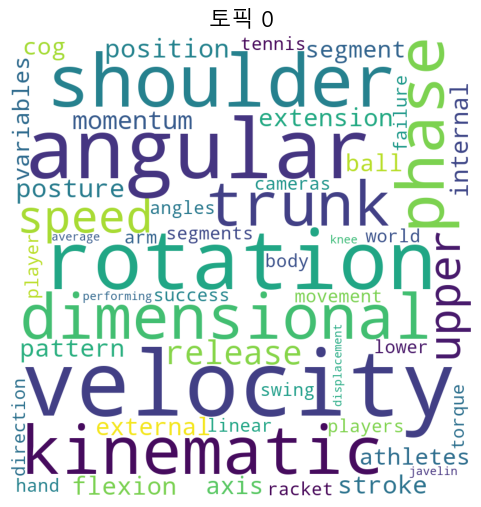

C:\Users\kimha\A\lib\site-packages\wordcloud\wordcloud.py:522: DeprecationWarning: ROTATE_90 is deprecated and will be removed in Pillow 10 (2023-07-01). Use Transpose.ROTATE_90 instead.
  orientation = (Image.ROTATE_90 if orientation is None else
C:\Users\kimha\A\lib\site-packages\wordcloud\wordcloud.py:522: DeprecationWarning: ROTATE_90 is deprecated and will be removed in Pillow 10 (2023-07-01). Use Transpose.ROTATE_90 instead.
  orientation = (Image.ROTATE_90 if orientation is None else


C:\Users\kimha\A\lib\site-packages\wordcloud\wordcloud.py:522: DeprecationWarning: ROTATE_90 is deprecated and will be removed in Pillow 10 (2023-07-01). Use Transpose.ROTATE_90 instead.
  orientation = (Image.ROTATE_90 if orientation is None else
C:\Users\kimha\A\lib\site-packages\wordcloud\wordcloud.py:522: DeprecationWarning: ROTATE_90 is deprecated and will be removed in Pillow 10 (2023-07-01). Use Transpose.ROTATE_90 instead.
  orientation = (Image.ROTATE_90 if orientation is None else
C:\Users\kimha\A\lib\site-packages\wordcloud\wordcloud.py:522: DeprecationWarning: ROTATE_90 is deprecated and will be removed in Pillow 10 (2023-07-01). Use Transpose.ROTATE_90 instead.
  orientation = (Image.ROTATE_90 if orientation is None else
C:\Users\kimha\A\lib\site-packages\wordcloud\wordcloud.py:522: DeprecationWarning: ROTATE_90 is deprecated and will be removed in Pillow 10 (2023-07-01). Use Transpose.ROTATE_90 instead.
  orientation = (Image.ROTATE_90 if orientation is None else
C:\Users

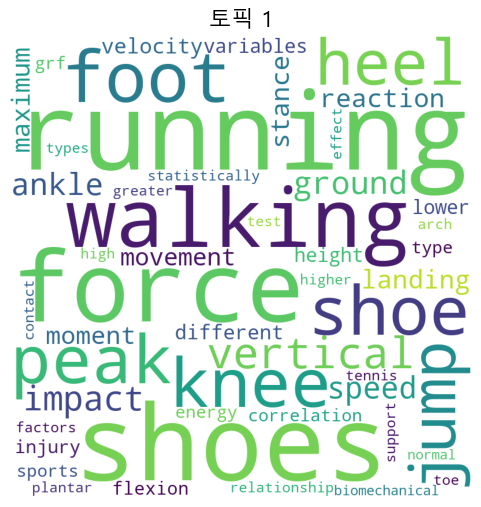

C:\Users\kimha\A\lib\site-packages\wordcloud\wordcloud.py:522: DeprecationWarning: ROTATE_90 is deprecated and will be removed in Pillow 10 (2023-07-01). Use Transpose.ROTATE_90 instead.
  orientation = (Image.ROTATE_90 if orientation is None else


C:\Users\kimha\A\lib\site-packages\wordcloud\wordcloud.py:522: DeprecationWarning: ROTATE_90 is deprecated and will be removed in Pillow 10 (2023-07-01). Use Transpose.ROTATE_90 instead.
  orientation = (Image.ROTATE_90 if orientation is None else
C:\Users\kimha\A\lib\site-packages\wordcloud\wordcloud.py:522: DeprecationWarning: ROTATE_90 is deprecated and will be removed in Pillow 10 (2023-07-01). Use Transpose.ROTATE_90 instead.
  orientation = (Image.ROTATE_90 if orientation is None else
C:\Users\kimha\A\lib\site-packages\wordcloud\wordcloud.py:522: DeprecationWarning: ROTATE_90 is deprecated and will be removed in Pillow 10 (2023-07-01). Use Transpose.ROTATE_90 instead.
  orientation = (Image.ROTATE_90 if orientation is None else
C:\Users\kimha\A\lib\site-packages\wordcloud\wordcloud.py:522: DeprecationWarning: ROTATE_90 is deprecated and will be removed in Pillow 10 (2023-07-01). Use Transpose.ROTATE_90 instead.
  orientation = (Image.ROTATE_90 if orientation is None else
C:\Users

C:\Users\kimha\A\lib\site-packages\wordcloud\wordcloud.py:522: DeprecationWarning: ROTATE_90 is deprecated and will be removed in Pillow 10 (2023-07-01). Use Transpose.ROTATE_90 instead.
  orientation = (Image.ROTATE_90 if orientation is None else


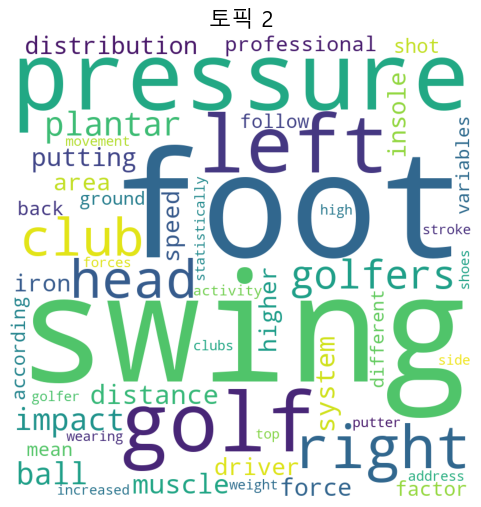

C:\Users\kimha\A\lib\site-packages\wordcloud\wordcloud.py:522: DeprecationWarning: ROTATE_90 is deprecated and will be removed in Pillow 10 (2023-07-01). Use Transpose.ROTATE_90 instead.
  orientation = (Image.ROTATE_90 if orientation is None else


C:\Users\kimha\A\lib\site-packages\wordcloud\wordcloud.py:522: DeprecationWarning: ROTATE_90 is deprecated and will be removed in Pillow 10 (2023-07-01). Use Transpose.ROTATE_90 instead.
  orientation = (Image.ROTATE_90 if orientation is None else
C:\Users\kimha\A\lib\site-packages\wordcloud\wordcloud.py:522: DeprecationWarning: ROTATE_90 is deprecated and will be removed in Pillow 10 (2023-07-01). Use Transpose.ROTATE_90 instead.
  orientation = (Image.ROTATE_90 if orientation is None else
C:\Users\kimha\A\lib\site-packages\wordcloud\wordcloud.py:522: DeprecationWarning: ROTATE_90 is deprecated and will be removed in Pillow 10 (2023-07-01). Use Transpose.ROTATE_90 instead.
  orientation = (Image.ROTATE_90 if orientation is None else
C:\Users\kimha\A\lib\site-packages\wordcloud\wordcloud.py:522: DeprecationWarning: ROTATE_90 is deprecated and will be removed in Pillow 10 (2023-07-01). Use Transpose.ROTATE_90 instead.
  orientation = (Image.ROTATE_90 if orientation is None else
C:\Users

C:\Users\kimha\A\lib\site-packages\wordcloud\wordcloud.py:499: DeprecationWarning: ROTATE_90 is deprecated and will be removed in Pillow 10 (2023-07-01). Use Transpose.ROTATE_90 instead.
  orientation = Image.ROTATE_90
C:\Users\kimha\A\lib\site-packages\wordcloud\wordcloud.py:499: DeprecationWarning: ROTATE_90 is deprecated and will be removed in Pillow 10 (2023-07-01). Use Transpose.ROTATE_90 instead.
  orientation = Image.ROTATE_90


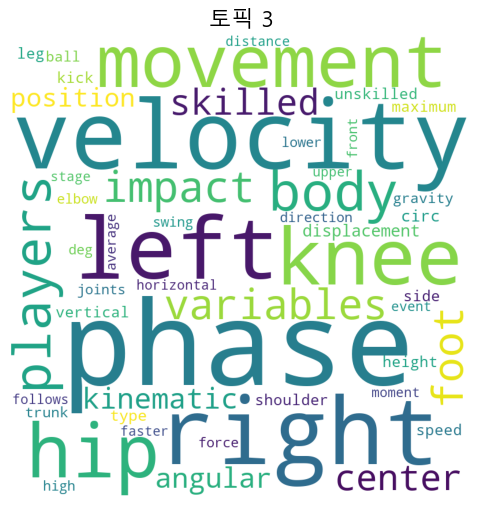

C:\Users\kimha\A\lib\site-packages\wordcloud\wordcloud.py:522: DeprecationWarning: ROTATE_90 is deprecated and will be removed in Pillow 10 (2023-07-01). Use Transpose.ROTATE_90 instead.
  orientation = (Image.ROTATE_90 if orientation is None else
C:\Users\kimha\A\lib\site-packages\wordcloud\wordcloud.py:522: DeprecationWarning: ROTATE_90 is deprecated and will be removed in Pillow 10 (2023-07-01). Use Transpose.ROTATE_90 instead.
  orientation = (Image.ROTATE_90 if orientation is None else


C:\Users\kimha\A\lib\site-packages\wordcloud\wordcloud.py:522: DeprecationWarning: ROTATE_90 is deprecated and will be removed in Pillow 10 (2023-07-01). Use Transpose.ROTATE_90 instead.
  orientation = (Image.ROTATE_90 if orientation is None else
C:\Users\kimha\A\lib\site-packages\wordcloud\wordcloud.py:499: DeprecationWarning: ROTATE_90 is deprecated and will be removed in Pillow 10 (2023-07-01). Use Transpose.ROTATE_90 instead.
  orientation = Image.ROTATE_90
C:\Users\kimha\A\lib\site-packages\wordcloud\wordcloud.py:523: DeprecationWarning: ROTATE_90 is deprecated and will be removed in Pillow 10 (2023-07-01). Use Transpose.ROTATE_90 instead.
  Image.ROTATE_90)
C:\Users\kimha\A\lib\site-packages\wordcloud\wordcloud.py:522: DeprecationWarning: ROTATE_90 is deprecated and will be removed in Pillow 10 (2023-07-01). Use Transpose.ROTATE_90 instead.
  orientation = (Image.ROTATE_90 if orientation is None else
C:\Users\kimha\A\lib\site-packages\wordcloud\wordcloud.py:522: DeprecationWarni

C:\Users\kimha\A\lib\site-packages\wordcloud\wordcloud.py:522: DeprecationWarning: ROTATE_90 is deprecated and will be removed in Pillow 10 (2023-07-01). Use Transpose.ROTATE_90 instead.
  orientation = (Image.ROTATE_90 if orientation is None else
C:\Users\kimha\A\lib\site-packages\wordcloud\wordcloud.py:499: DeprecationWarning: ROTATE_90 is deprecated and will be removed in Pillow 10 (2023-07-01). Use Transpose.ROTATE_90 instead.
  orientation = Image.ROTATE_90
C:\Users\kimha\A\lib\site-packages\wordcloud\wordcloud.py:522: DeprecationWarning: ROTATE_90 is deprecated and will be removed in Pillow 10 (2023-07-01). Use Transpose.ROTATE_90 instead.
  orientation = (Image.ROTATE_90 if orientation is None else
C:\Users\kimha\A\lib\site-packages\wordcloud\wordcloud.py:522: DeprecationWarning: ROTATE_90 is deprecated and will be removed in Pillow 10 (2023-07-01). Use Transpose.ROTATE_90 instead.
  orientation = (Image.ROTATE_90 if orientation is None else
C:\Users\kimha\A\lib\site-packages\wo

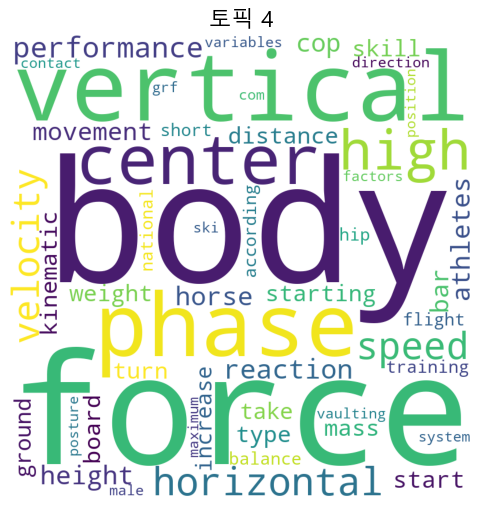

C:\Users\kimha\A\lib\site-packages\wordcloud\wordcloud.py:522: DeprecationWarning: ROTATE_90 is deprecated and will be removed in Pillow 10 (2023-07-01). Use Transpose.ROTATE_90 instead.
  orientation = (Image.ROTATE_90 if orientation is None else


C:\Users\kimha\A\lib\site-packages\wordcloud\wordcloud.py:522: DeprecationWarning: ROTATE_90 is deprecated and will be removed in Pillow 10 (2023-07-01). Use Transpose.ROTATE_90 instead.
  orientation = (Image.ROTATE_90 if orientation is None else
C:\Users\kimha\A\lib\site-packages\wordcloud\wordcloud.py:499: DeprecationWarning: ROTATE_90 is deprecated and will be removed in Pillow 10 (2023-07-01). Use Transpose.ROTATE_90 instead.
  orientation = Image.ROTATE_90
C:\Users\kimha\A\lib\site-packages\wordcloud\wordcloud.py:499: DeprecationWarning: ROTATE_90 is deprecated and will be removed in Pillow 10 (2023-07-01). Use Transpose.ROTATE_90 instead.
  orientation = Image.ROTATE_90
C:\Users\kimha\A\lib\site-packages\wordcloud\wordcloud.py:523: DeprecationWarning: ROTATE_90 is deprecated and will be removed in Pillow 10 (2023-07-01). Use Transpose.ROTATE_90 instead.
  Image.ROTATE_90)
C:\Users\kimha\A\lib\site-packages\wordcloud\wordcloud.py:522: DeprecationWarning: ROTATE_90 is deprecated a

C:\Users\kimha\A\lib\site-packages\wordcloud\wordcloud.py:522: DeprecationWarning: ROTATE_90 is deprecated and will be removed in Pillow 10 (2023-07-01). Use Transpose.ROTATE_90 instead.
  orientation = (Image.ROTATE_90 if orientation is None else
C:\Users\kimha\A\lib\site-packages\wordcloud\wordcloud.py:522: DeprecationWarning: ROTATE_90 is deprecated and will be removed in Pillow 10 (2023-07-01). Use Transpose.ROTATE_90 instead.
  orientation = (Image.ROTATE_90 if orientation is None else
C:\Users\kimha\A\lib\site-packages\wordcloud\wordcloud.py:522: DeprecationWarning: ROTATE_90 is deprecated and will be removed in Pillow 10 (2023-07-01). Use Transpose.ROTATE_90 instead.
  orientation = (Image.ROTATE_90 if orientation is None else


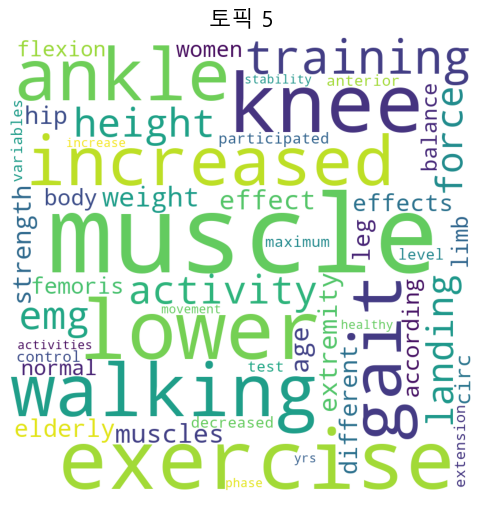

In [34]:
# ============================================
# 1️⃣3️⃣ 토픽별 워드클라우드 시각화
# ============================================
for i in range(lda_model.num_topics):
    plt.figure(figsize=(6, 6))
    plt.imshow(
        WordCloud(
            background_color="white",
            width=800, height=800
        ).generate_from_frequencies(dict(lda_model.show_topic(i, 50)))
    )
    plt.axis("off")
    plt.title(f"토픽 {i}", fontsize=16)
    plt.show()

## 시기별 토픽 변화

논문이 1994년부터 2024년까지 31년에 걸쳐 있다.
논문마다 토픽 비중이 있으니, 시기별로 평균을 내면 어떤 주제가 늘고 줄었는지 볼 수 있다.
이걸 보는 게 이 분석의 목적이다.

In [35]:
# ============================================
# 1️⃣4️⃣ 논문마다 토픽 비중 구하기
# ============================================
import numpy as np

비중 = np.zeros((len(corpus), lda_model.num_topics))

for i, bow in enumerate(corpus):
    for topic, p in lda_model.get_document_topics(bow, minimum_probability=0.0):
        비중[i, topic] = p

print(비중.shape)

(1120, 6)


In [36]:
# ============================================
# 1️⃣5️⃣ 5년 단위로 묶어서 평균 비중 계산
# ============================================
구간 = [(1994, 1999), (2000, 2004), (2005, 2009),
       (2010, 2014), (2015, 2019), (2020, 2024)]

라벨 = []
표 = []

for lo, hi in 구간:
    골라내기 = (data['연도'] >= lo) & (data['연도'] <= hi)
    라벨.append(f'{lo}~{hi}')
    표.append(비중[골라내기.values].mean(axis=0))

표 = np.array(표)

for j, label in enumerate(라벨):
    print(label, [f'{v*100:.1f}%' for v in 표[j]])

1994~1999 ['19.3%', '13.0%', '8.7%', '34.4%', '17.6%', '7.0%']
2000~2004 ['15.9%', '14.2%', '11.8%', '31.1%', '17.1%', '9.8%']
2005~2009 ['12.3%', '18.6%', '13.1%', '17.3%', '14.5%', '24.2%']
2010~2014 ['14.1%', '12.6%', '12.6%', '14.0%', '11.0%', '35.5%']
2015~2019 ['5.4%', '16.5%', '12.9%', '7.0%', '12.5%', '45.6%']
2020~2024 ['5.8%', '16.2%', '8.9%', '5.2%', '11.3%', '52.7%']


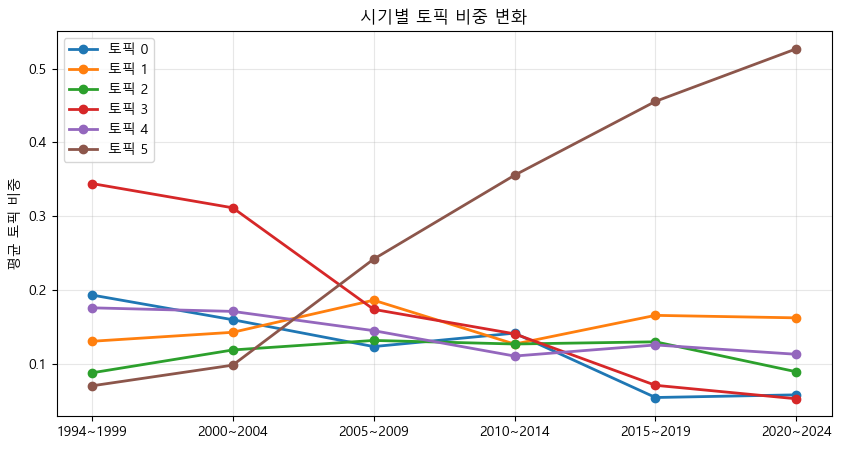

In [37]:
# ============================================
# 1️⃣6️⃣ 그래프로 확인
# ============================================
plt.figure(figsize=(10, 5))

for i in range(lda_model.num_topics):
    plt.plot(라벨, 표[:, i], marker='o', linewidth=2, label=f'토픽 {i}')

plt.ylabel('평균 토픽 비중')
plt.title('시기별 토픽 비중 변화')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [38]:
# ============================================
# 1️⃣7️⃣ 처음과 마지막 구간 비교
# ============================================
for i in range(lda_model.num_topics):
    변화 = (표[-1, i] - 표[0, i]) * 100
    print(f'토픽 {i}: {표[0, i]*100:5.1f}% → {표[-1, i]*100:5.1f}%  ({변화:+.1f}%p)')

토픽 0:  19.3% →   5.8%  (-13.5%p)
토픽 1:  13.0% →  16.2%  (+3.2%p)
토픽 2:   8.7% →   8.9%  (+0.1%p)
토픽 3:  34.4% →   5.2%  (-29.2%p)
토픽 4:  17.6% →  11.3%  (-6.3%p)
토픽 5:   7.0% →  52.7%  (+45.7%p)
